<a href="https://colab.research.google.com/github/fbsilvaRP/ComputerVision-Fundamentals/blob/main/RedesNeurais_Estruturado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Configurações Iniciais


---




1.   **Célula de SETUP 1 -  Organização do ambiente e extração de dados**;
2.   **Célula de SETUP 2 - Criação do dataframe**;
3.   **Célula de SETUP 3 - Filtrar 200x e remover pacientes com múltiplas classes**;
4.  **Célula de SETUP 4 - Mapeamento para 2 classes (Benigno/maligno)**;
5.  **Célula de SETUP 5 - Divisão 70:15:15 por paciente**;
6.  **Célula de SETUP 6 - Salvando o dataframe.**



## **1.1.Organização**


---
A célula abaixo realiza as seguintes etapas:

1.   Testes da GPU (Verificação);
2.   Importação da base de dados EBHI do google drive.






In [39]:
import torch
import os
import shutil
from google.colab import drive

# --- Seção de apresentação inicial ---
print("=-" * 30)
print("Primeira célula de setup - Versão 1")
print("Última atualização em 12 de Agosto de 2026")
print("=-" * 30)

# ---1. Verificação da GPU ---
print("Etapa 1: Verificação da GPU")
print("-=" * 30)

print("Versão do PyTorch: ", torch.__version__) #Versão do PyTorch em uso;

resposta = torch.cuda.is_available()            #Verificação se a GPU está disponível para uso (1 ou 0);

if(resposta):
  nomeGPU = torch.cuda.get_device_name(0)       #Verifica o nome da GPU em uso;
  print(f"Nome da GPU: {nomeGPU}")              #Apresenta o nome obtido;
  device = torch.device('cuda')                 #Atribui a identificação para a GPU;
else:
  print("GPU não disponível. Usando CPU.")
  device = torch.device('cpu')                  #Atribui a identificação para a CPU;

# --- 2.Importando a base de imagens EBHI ---

!apt-get install unrar -y                       #Instala o unrar a partir da linha de comando (comando do linux);

drive.mount('/content/drive')                   #Estabelece a conexão com o Google Drive;

origem_rar  =   '/content/drive/MyDrive/EBH-HE-IDS.rar' #Definição da origem da base de imagens (arquivo rar);
destino_rar =   '/content/EBHI.rar'                     #Definição de onde o arquivo (rar) será colocado - Voltar um diretório;
pasta_destino = '/content/EBHI'                         #Pasta onde o arquivo será extraído;

if os.path.exists(pasta_destino):                       #Se o diretório já existir, ele será apagado;
  shutil.rmtree(pasta_destino)                          #Apaga um diretório preeexistente, se existir;
  print("Arquivo preexistente apagado.")


shutil.copy(origem_rar, destino_rar)                  #Cópia do Drive para a máquina local do Colab;

!unrar x {destino_rar} {pasta_destino}/           #Realiza a descompactação do arquivo (comando linux);

print("Configuração concluída!")                      #Mensagem de conclusão;

A saída de streaming foi truncada nas últimas 5000 linhas.
Extracting  /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/100/2016780-1-100-004.jpg      43%  OK 
Extracting  /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/100/2016780-1-100-005.jpg      43%  OK 
Extracting  /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/100/2016780-1-100-006.jpg      43%  OK 
Extracting  /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/100/2016780-1-100-007.jpg      43%  OK 
Creating    /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/200  OK
Extracting  /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/200/2016780-1-200-001.jpg      43%  OK 
Extracting  /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/200/2016780-1-200-002.jpg      43%  OK 
Extracting  /content/EBHI/ColHis-IDS/High-grade IN/20210115-2016780-1/200/2016780-1-200-003.jpg      43%  OK 
Creating    /content/EBHI/ColH

## **1.2.Criação do dataframe**


---
O dataframe funcionará como uma planilha.

**Etapas:**

1.   Criação do dataframe;
2.   Apresentação das quantidades de imagens + proporção inicial de imagens.


**Observação:** Para a classificação a ser realizada, será utilizada apenas a **magnificação 200x** (sugestão do artigo).



In [40]:
import os
import pandas as pd

caminho_base = '/content/EBHI/ColHis-IDS' #Define a pasta onde a busca por imagens será feita

registros = [] #Lista vazia (futuro dataframe)

for pasta_atual, subpastas, arquivos in os.walk(caminho_base):    #os.walk() função que percorre todos os diretórios a partir do caminho base;
  for arquivo in arquivos:
    #Dentro de cada pasta visitada, o loop passa por cada arquivo individualmente
    if arquivo.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):     #Filtra para processar só arquivos de imagem;
      #endswith verifica se o nome termina com qualquer uma das extensões da tupla
      caminho_completo = os.path.join(pasta_atual, arquivo)             #Junta o caminho da pasta atual com o nome do arquivo, formando o caminho completo até o arquivo específico;

      partes = caminho_completo.replace(caminho_base, '').strip(os.sep).split(os.sep)

      if len(partes) == 4:
        classe, paciente, magnificacao, nome_arquivo = partes
        registros.append({
            'caminho': caminho_completo,
            'classe_5': classe,
            'paciente': paciente,
            'magnificacao': magnificacao,
            'arquivo': nome_arquivo
        })

df = pd.DataFrame(registros)

#Inserindo os dados obtidos em variáveis (p/apresentar)
totalImagens = len(df)
totalClasses = df['classe_5'].value_counts()
Mag = df['magnificacao'].value_counts()
TotalPacientes = df['paciente'].nunique()

# --- Apresentando o conteúdo obtido ---

print("=" * 50)
print("RESUMO DO DATAFRAME MASTER — BASE EBHI")
print("=" * 50)

print(f"\nTotal de imagens: {totalImagens}")

print(f"\n{'Classes encontradas':-^40}")

for classe, quantidade in totalClasses.items():
    percentual = (quantidade / totalImagens) * 100
    print(f"  {classe:<20} {quantidade:>5}  ({percentual:5.1f}%)")

print(f"\n{'Magnificações encontradas':-^40}")

for magnificacao, quantidade in Mag.items():
    percentual = (quantidade / totalImagens) * 100
    print(f"  {magnificacao + 'x':<20} {quantidade:>5}  ({percentual:5.1f}%)")

print(f"\nTotal de pacientes/lâminas únicas: {TotalPacientes}")
print("=" * 50)

# tabela cruzada: linhas = classe, colunas = magnificação, valores = contagem
tabela_cruzada = pd.crosstab(
    df['classe_5'],
    df['magnificacao'],
    margins= True,           # adiciona linha e coluna de "Total"
    margins_name= 'Total'
)

# reordena as colunas para ficar 40, 100, 200, 400, Total (mesma ordem do artigo)
ordem_colunas = ['40', '100', '200', '400', 'Total']
tabela_cruzada = tabela_cruzada[ordem_colunas]

# reordena as linhas para bater com a ordem do artigo (Normal, Polyp, Low-grade IN, High-grade IN, Adenocarcinoma, Total)
ordem_linhas = ['Normal', 'Polyp', 'Low-grade IN', 'High-grade IN', 'Adenocarcinoma', 'Total']
tabela_cruzada = tabela_cruzada.reindex(ordem_linhas)

print(f"\n{'Tabela com os dados cruzados(Artigo)':-^50}")
print("=" * 50)

print(tabela_cruzada)
print("=" * 50)

RESUMO DO DATAFRAME MASTER — BASE EBHI

Total de imagens: 5532

----------Classes encontradas-----------
  Adenocarcinoma        2278  ( 41.2%)
  Low-grade IN          1808  ( 32.7%)
  Polyp                  842  ( 15.2%)
  High-grade IN          418  (  7.6%)
  Normal                 186  (  3.4%)

-------Magnificações encontradas--------
  400x                  2016  ( 36.4%)
  200x                  1838  ( 33.2%)
  100x                  1086  ( 19.6%)
  40x                    592  ( 10.7%)

Total de pacientes/lâminas únicas: 507

-------Tabela com os dados cruzados(Artigo)-------
magnificacao    40    100   200   400  Total
classe_5                                    
Normal           17    29    61    79   186 
Polyp           119   165   254   304   842 
Low-grade IN    204   341   603   660  1808 
High-grade IN    47    80   130   161   418 
Adenocarcinoma  205   471   790   812  2278 
Total           592  1086  1838  2016  5532 


## **1.3.Filtro 200x e remoções**


---


1.   Apenas as imagens com a amplicação 200x são consideradas (conforme o artigo apresenta).
2.   Os pacientes com múltiplas categorias são removidos, uma vez que:


  *   Nenhum critério de distinção novo será criado (como "qual é o estágio mais severo");
  *   O custo da remoção foi baixo: de um total de 1838 em 200x, apenas 89 imagens (4,8%) apresentavam pacientes com mais de uma classe de diferenciação tumoral.

  **A remoção ocorre para evitar vazamentos de dados entre teino e teste.**







In [41]:
# ====================================================================
# Filtragem por magnificação (200x) e limpeza de pacientes ambíguos
# ====================================================================

# --- 1. Filtra apenas as imagens de magnificação 200x ---
df_200 = df[df['magnificacao'] == '200'].reset_index(drop=True)

print(f"Imagens em 200x: {len(df_200)}")
assert len(df_200) == 1838, f"Esperado 1838 imagens em 200x, encontrado {len(df_200)}"

# --- 2. Identifica pacientes com mais de uma classe associada ---
pacientes_por_classe = df_200.groupby('paciente')['classe_5'].nunique()
pacientes_multiclasse = pacientes_por_classe[pacientes_por_classe > 1].index.tolist()

print(f"\nPacientes com múltiplas classes: {len(pacientes_multiclasse)}")

# mostra o detalhe de cada um, para conferência
for p in pacientes_multiclasse:
    classes = df_200[df_200['paciente'] == p]['classe_5'].unique()
    n_imagens = df_200[df_200['paciente'] == p].shape[0]
    print(f"  {p}: classes = {list(classes)}, imagens = {n_imagens}")

# --- 3. Remove esses pacientes do dataframe ---
imagens_antes = len(df_200)
df_200 = df_200[~df_200['paciente'].isin(pacientes_multiclasse)].reset_index(drop=True)
imagens_depois = len(df_200)

print(f"\nImagens antes da limpeza: {imagens_antes}")
print(f"Imagens depois da limpeza: {imagens_depois}")
print(f"Imagens removidas: {imagens_antes - imagens_depois}")

# --- 4. Confirma que não sobrou nenhum paciente multiclasse ---
checagem = df_200.groupby('paciente')['classe_5'].nunique()
assert (checagem > 1).sum() == 0, "Ainda há pacientes com múltiplas classes!"

# --- 5. Resumo final ---
print(f"\n{'RESUMO FINAL (200x, limpo)':-^40}")
print(f"Total de imagens: {len(df_200)}")
print(f"Total de pacientes: {df_200['paciente'].nunique()}")
print(f"\nDistribuição por classe:")
for classe, qtd in df_200['classe_5'].value_counts().items():
    pct = (qtd / len(df_200)) * 100
    print(f"  {classe:<20} {qtd:>5}  ({pct:5.1f}%)")

Imagens em 200x: 1838

Pacientes com múltiplas classes: 14
  20201120-2014662-1: classes = ['Adenocarcinoma', 'High-grade IN'], imagens = 3
  20201120-2014789-1: classes = ['Low-grade IN', 'Polyp'], imagens = 4
  20201216-2014780-1: classes = ['Low-grade IN', 'Polyp'], imagens = 3
  20201216-2017351-1: classes = ['High-grade IN', 'Low-grade IN'], imagens = 5
  20210112-2100093-1: classes = ['Normal', 'Low-grade IN'], imagens = 3
  20210112-2100093-4: classes = ['Normal', 'High-grade IN'], imagens = 3
  20210215-xc2012796-1: classes = ['Low-grade IN', 'Polyp'], imagens = 7
  20210215-xc2012827-1: classes = ['Normal', 'Low-grade IN'], imagens = 5
  20210215-xc2012827-2: classes = ['Normal', 'Low-grade IN'], imagens = 5
  20210711-XC2015362-1: classes = ['High-grade IN', 'Low-grade IN'], imagens = 3
  20210711-XC2015362-9: classes = ['Adenocarcinoma', 'High-grade IN'], imagens = 18
  20210711-XC2015371-1: classes = ['Adenocarcinoma', 'High-grade IN'], imagens = 10
  20210711-XC2015381-1: 

## **1.4.Mapeamento (2 classes)**


---



1.  **Obtém a informação das classes já existentes (5 categorias)**;
2.   **Cria uma versão simplificada (2 categorias)**.





In [42]:
# ============================================================
# Mapeamento para 2 classes (Benigno/Maligno)
# ============================================================

#Criação de um dicionário para realizar o mapeamento
mapa_2_classes = {
    'Normal': 'Benigno',
    'Polyp': 'Benigno',
    'Low-grade IN': 'Benigno',
    'High-grade IN': 'Maligno',
    'Adenocarcinoma': 'Maligno'
}


df_200['classe_2'] = df_200['classe_5'].map(mapa_2_classes)

# confere se todas as linhas foram mapeadas (nenhum valor nulo/NaN)
assert df_200['classe_2'].isnull().sum() == 0, "Existem classes não mapeadas!"

print(f"{'Distribuição — 2 classes':-^40}")
for classe, qtd in df_200['classe_2'].value_counts().items():
    pct = (qtd / len(df_200)) * 100
    print(f"  {classe:<20} {qtd:>5}  ({pct:5.1f}%)")

--------Distribuição — 2 classes--------
  Maligno                875  ( 50.0%)
  Benigno                874  ( 50.0%)


## **1.5.Divisão (70:15:15)**


---


1. Divisão dos pacientes (não as imagens diretamente) em três grupos: treino, validação e teste (70/15/15). A divisão é feita de forma balanceada por classe;
2. Marca cada imagem com o grupo do seu paciente.

**OBS: A biblioteca scikit-learn permite as divisões aleatórias e controladas de um conjunto de dados.**


In [43]:
# ============================================================
# Split 70/15/15 por paciente (estratificado por classe_5)
# ============================================================

from sklearn.model_selection import train_test_split

# --- 1. Uma linha por paciente (cada paciente já tem 1 única classe, após a limpeza) ---
pacientes_df = df_200.groupby('paciente')['classe_5'].first().reset_index()
print(f"Total de pacientes únicos: {len(pacientes_df)}")

# --- 2. Primeira divisão: 70% treino, 30% resto --- 2 grupos
pacientes_treino, pacientes_resto = train_test_split(
    pacientes_df,
    test_size = 0.30,
    stratify = pacientes_df['classe_5'],
    random_state = 42
)

# --- 3. Segunda divisão: o "resto" (30%) vira 15% val + 15% teste ---
pacientes_val, pacientes_teste = train_test_split(
    pacientes_resto,
    test_size = 0.50,
    stratify = pacientes_resto['classe_5'],
    random_state = 42
)

print(f"\nPacientes — treino: {len(pacientes_treino)}, val: {len(pacientes_val)}, teste: {len(pacientes_teste)}")

# --- 4. Propaga o split de paciente para cada imagem ---
def definir_split(paciente):
    if paciente in pacientes_treino['paciente'].values:
        return 'treino'
    elif paciente in pacientes_val['paciente'].values:
        return 'validacao'
    else:
        return 'teste'

df_200['split'] = df_200['paciente'].apply(definir_split)

# --- 5. Verificações ---
print(f"\n{'Distribuição de imagens por split':-^40}")
for split_nome, qtd in df_200['split'].value_counts().items():
    pct = (qtd / len(df_200)) * 100
    print(f"  {split_nome:<20} {qtd:>5}  ({pct:5.1f}%)")

# checa se nenhuma imagem ficou sem split atribuído
assert df_200['split'].isnull().sum() == 0, "Existem imagens sem split!"

# checa se a soma bate com o total
assert df_200['split'].value_counts().sum() == len(df_200), "Split não cobre todas as imagens!"

print(f"\n{'Proporção de classes dentro de cada split (checagem)':-^55}")
print(df_200.groupby('split')['classe_5'].value_counts(normalize=True).round(3).to_string())

Total de pacientes únicos: 490

Pacientes — treino: 343, val: 73, teste: 74

---Distribuição de imagens por split----
  treino                1216  ( 69.5%)
  teste                  268  ( 15.3%)
  validacao              265  ( 15.2%)

-Proporção de classes dentro de cada split (checagem)--
split      classe_5      
teste      Adenocarcinoma    0.485
           Low-grade IN      0.328
           Polyp             0.119
           High-grade IN     0.049
           Normal            0.019
treino     Adenocarcinoma    0.425
           Low-grade IN      0.320
           Polyp             0.150
           High-grade IN     0.069
           Normal            0.035
validacao  Adenocarcinoma    0.442
           Low-grade IN      0.377
           Polyp             0.106
           High-grade IN     0.053
           Normal            0.023


## **1.6.Salvando o dataframe**


---

O arquivo CSV criado é chamado de **manifesto**;

*   O manifesto contém **todas as decisões e metadados obtido**s: **89 imagens removidas**, **mapeamento para 2 classes** e a **divisão de treino/validação/teste de cada imagem**.







In [44]:
caminho_salvar = '/content/drive/MyDrive/manifesto_ebhi_200x.csv'
df_200.to_csv(caminho_salvar, index = False)
print(f"Manifesto salvo em: {caminho_salvar}")

Manifesto salvo em: /content/drive/MyDrive/manifesto_ebhi_200x.csv


# 2.Transformações


---



1.   **Aplicando as transformações necessárias**;
2.   **Criação dos DataLoaders**;
3.   **Função para carregar um modelo de rede neural**;
4.   **Função de treino**.



## **2.1.Aplicando**


---



In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ---------------------------------------------------------
# Transformações para TREINO (com data augmentation)
# ---------------------------------------------------------
transform_treino = transforms.Compose([
    transforms.Resize((224, 224)),           # redimensiona toda imagem para 224x224
    transforms.RandomHorizontalFlip(p=0.5),  # 50% de chance de espelhar horizontalmente
    transforms.RandomRotation(degrees=15),   # gira aleatoriamente até 15 graus
    transforms.ToTensor(),                   # converte de imagem PIL para tensor PyTorch (e escala 0-255 -> 0-1)
    transforms.Normalize(                    # normaliza usando as estatísticas do ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------------------------------------
# Transformações para VALIDAÇÃO e TESTE (sem augmentation)
# ---------------------------------------------------------
transform_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ---------------------------------------------------------
# Classe Dataset customizada
# ---------------------------------------------------------
class EBHIDataset(Dataset):
    def __init__(self, dataframe, coluna_classe, transform=None):
        """
        dataframe: o df_200 já filtrado para o split desejado (treino, val ou teste)
        coluna_classe: 'classe_2' ou 'classe_5', dependendo do experimento
        transform: qual conjunto de transformações aplicar
        """
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.coluna_classe = coluna_classe

        # mapeia nomes de classe (texto) para números, que é o que a rede espera
        # ex: {'Benigno': 0, 'Maligno': 1} ou {'Normal': 0, 'Polyp': 1, ...}
        classes_unicas = sorted(self.df[coluna_classe].unique())
        self.classe_para_indice = {nome: i for i, nome in enumerate(classes_unicas)}
        self.indice_para_classe = {i: nome for nome, i in self.classe_para_indice.items()}

    def __len__(self):
        # quantas imagens existem nesse dataset
        return len(self.df)

    def __getitem__(self, idx):
        # pega a linha correspondente do manifesto
        linha = self.df.iloc[idx]

        # abre a imagem de verdade a partir do caminho salvo no manifesto
        imagem = Image.open(linha['caminho']).convert('RGB')  # garante 3 canais (RGB)

        # aplica as transformações (resize, augmentation, normalização)
        if self.transform:
            imagem = self.transform(imagem)

        # converte o nome da classe (texto) para o número correspondente
        rotulo = self.classe_para_indice[linha[self.coluna_classe]]

        return imagem, rotulo

## **2.2.DataLoaders**


---



In [8]:
# separando o manifesto por split
df_treino = df_200[df_200['split'] == 'treino']
df_val = df_200[df_200['split'] == 'validacao']
df_teste = df_200[df_200['split'] == 'teste']

# criando os Datasets (exemplo com classe_2 = Benigno/Maligno)
dataset_treino = EBHIDataset(df_treino, coluna_classe='classe_2', transform=transform_treino)
dataset_val = EBHIDataset(df_val, coluna_classe='classe_2', transform=transform_eval)
dataset_teste = EBHIDataset(df_teste, coluna_classe='classe_2', transform=transform_eval)

# criando os DataLoaders
loader_treino = DataLoader(dataset_treino, batch_size=32, shuffle=True, num_workers=2)
loader_val = DataLoader(dataset_val, batch_size=32, shuffle=False, num_workers=2)
loader_teste = DataLoader(dataset_teste, batch_size=32, shuffle=False, num_workers=2)

print(f"Batches de treino: {len(loader_treino)}")
print(f"Batches de validação: {len(loader_val)}")
print(f"Batches de teste: {len(loader_teste)}")
print(f"\nMapeamento de classes: {dataset_treino.classe_para_indice}")

Batches de treino: 38
Batches de validação: 9
Batches de teste: 9

Mapeamento de classes: {'Benigno': 0, 'Maligno': 1}


# 3.Treinamento

## **3.1.modelo de rede neural**


---



In [9]:
import torch.nn as nn
from torchvision import models

def carregar_modelo(nome_modelo, num_classes):
    """
    Carrega um modelo pré-treinado (ImageNet) e adapta a última camada
    para o número de classes do nosso problema (2 ou 5).
    """

    if nome_modelo == 'resnet18':
        modelo = models.resnet18(weights='IMAGENET1K_V1')
        # a última camada da ResNet18 se chama 'fc' (fully connected)
        # pegamos quantas entradas ela espera, e substituímos a saída
        num_features = modelo.fc.in_features
        modelo.fc = nn.Linear(num_features, num_classes)

    elif nome_modelo == 'alexnet':
        modelo = models.alexnet(weights='IMAGENET1K_V1')
        # na AlexNet, o classificador é um bloco (Sequential) de várias camadas
        # a última camada desse bloco é o índice [6]
        num_features = modelo.classifier[6].in_features
        modelo.classifier[6] = nn.Linear(num_features, num_classes)

    elif nome_modelo == 'vgg16':
        modelo = models.vgg16(weights='IMAGENET1K_V1')
        # a VGG16 também tem um bloco 'classifier', com a última camada no índice [6]
        num_features = modelo.classifier[6].in_features
        modelo.classifier[6] = nn.Linear(num_features, num_classes)

    else:
        raise ValueError(f"Modelo '{nome_modelo}' não reconhecido")

    return modelo

## **3.2.Função de treino**


---



In [10]:
import time

def treinar_modelo(modelo, loader_treino, loader_val, criterio, otimizador, device, num_epocas=15):
    """
    Treina o modelo por um número de épocas, avaliando em validação a cada época.
    Retorna o histórico de perdas/acurácias, para plotarmos depois.
    """
    historico = {
        'treino_loss': [], 'treino_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoca in range(num_epocas):
        inicio = time.time()

        # ---------------------------
        # FASE DE TREINO
        # ---------------------------
        modelo.train()  # coloca o modelo em modo de treino (ativa dropout, batchnorm em modo treino, etc.)

        perda_total = 0.0
        acertos = 0
        total_imagens = 0

        for imagens, rotulos in loader_treino:
            imagens = imagens.to(device)
            rotulos = rotulos.to(device)

            otimizador.zero_grad()  # zera os gradientes acumulados do lote anterior

            saida = modelo(imagens)              # forward pass
            perda = criterio(saida, rotulos)      # calcula o erro

            perda.backward()   # backward pass: calcula os gradientes
            otimizador.step()  # atualiza os pesos do modelo

            perda_total += perda.item() * imagens.size(0)
            _, previsoes = torch.max(saida, 1)  # pega a classe com maior "score" como previsão
            acertos += (previsoes == rotulos).sum().item()
            total_imagens += imagens.size(0)

        treino_loss = perda_total / total_imagens
        treino_acc = acertos / total_imagens

        # ---------------------------
        # FASE DE VALIDAÇÃO
        # ---------------------------
        modelo.eval()  # coloca o modelo em modo de avaliação (desativa dropout, etc.)

        perda_val_total = 0.0
        acertos_val = 0
        total_val = 0

        with torch.no_grad():  # desativa o cálculo de gradientes (mais rápido, não precisamos treinar aqui)
            for imagens, rotulos in loader_val:
                imagens = imagens.to(device)
                rotulos = rotulos.to(device)

                saida = modelo(imagens)
                perda = criterio(saida, rotulos)

                perda_val_total += perda.item() * imagens.size(0)
                _, previsoes = torch.max(saida, 1)
                acertos_val += (previsoes == rotulos).sum().item()
                total_val += imagens.size(0)

        val_loss = perda_val_total / total_val
        val_acc = acertos_val / total_val

        # guarda no histórico
        historico['treino_loss'].append(treino_loss)
        historico['treino_acc'].append(treino_acc)
        historico['val_loss'].append(val_loss)
        historico['val_acc'].append(val_acc)

        tempo_epoca = time.time() - inicio
        print(f"Época {epoca+1}/{num_epocas} | "
              f"Treino: loss={treino_loss:.4f}, acc={treino_acc:.4f} | "
              f"Val: loss={val_loss:.4f}, acc={val_acc:.4f} | "
              f"Tempo: {tempo_epoca:.1f}s")

    return historico

## **3.3.Treinando a rede**


---



In [ ]:
import os
import json

# pasta no Drive para salvar tudo
pasta_resultados = '/content/drive/MyDrive/resultados_ebhi'
os.makedirs(pasta_resultados, exist_ok=True)

# as 3 arquiteturas e os 2 cenários que vamos combinar
arquiteturas = ['resnet18', 'alexnet', 'vgg16']
cenarios = ['classe_2', 'classe_5']

NUM_EPOCAS = 20
resultados_gerais = {}

for cenario in cenarios:
    # descobre quantas classes esse cenário tem (2 ou 5)
    num_classes = df_200[cenario].nunique()

    # recria os Datasets/DataLoaders para esse cenário específico
    # (a única coisa que muda é a coluna de classe usada)
    dataset_treino = EBHIDataset(df_treino, coluna_classe=cenario, transform=transform_treino)
    dataset_val = EBHIDataset(df_val, coluna_classe=cenario, transform=transform_eval)

    loader_treino_atual = DataLoader(dataset_treino, batch_size=32, shuffle=True, num_workers=2)
    loader_val_atual = DataLoader(dataset_val, batch_size=32, shuffle=False, num_workers=2)

    for arquitetura in arquiteturas:
        nome_experimento = f"{arquitetura}_{cenario}"
        print(f"\n{'='*60}")
        print(f"Iniciando treino: {nome_experimento} ({num_classes} classes)")
        print(f"{'='*60}")

        # carrega o modelo do zero para esse experimento
        modelo = carregar_modelo(arquitetura, num_classes=num_classes).to(device)
        criterio = nn.CrossEntropyLoss()
        otimizador = torch.optim.Adam(modelo.parameters(), lr=0.0001)

        # treina
        historico = treinar_modelo(
            modelo, loader_treino_atual, loader_val_atual,
            criterio, otimizador, device,
            num_epocas=NUM_EPOCAS
        )

        # salva o modelo treinado (os pesos) direto no Drive
        caminho_modelo = os.path.join(pasta_resultados, f"{nome_experimento}.pth")
        torch.save(modelo.state_dict(), caminho_modelo)

        # salva o histórico de treino (perdas/acurácias por época) em JSON
        caminho_historico = os.path.join(pasta_resultados, f"{nome_experimento}_historico.json")
        with open(caminho_historico, 'w') as f:
            json.dump(historico, f)

        # salva também o mapeamento de classes usado (importante para a avaliação depois)
        caminho_mapeamento = os.path.join(pasta_resultados, f"{nome_experimento}_mapeamento.json")
        with open(caminho_mapeamento, 'w') as f:
            json.dump(dataset_treino.classe_para_indice, f)

        resultados_gerais[nome_experimento] = historico

        print(f"✅ {nome_experimento} salvo com sucesso em {pasta_resultados}")

print("\n\n🎉 Todos os 6 modelos foram treinados e salvos!")

# 4.Verificando a rede


---



**Reconecta ao drive e verifica se os arquivos foram salvos**

In [11]:
from google.colab import drive
drive.mount('/content/drive')

import os

pasta_resultados = '/content/drive/MyDrive/resultados_ebhi'
arquivos_salvos = os.listdir(pasta_resultados)

print(f"Total de arquivos na pasta: {len(arquivos_salvos)}")
for arquivo in sorted(arquivos_salvos):
    print(f"  {arquivo}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de arquivos na pasta: 24
  alexnet_classe_2.pth
  alexnet_classe_2_historico.json
  alexnet_classe_2_mapeamento.json
  alexnet_classe_5.pth
  alexnet_classe_5_historico.json
  alexnet_classe_5_mapeamento.json
  avaliacao_teste_completa.json
  curvas_treino.png
  matrizes_confusao.png
  resnet18_classe_2.pth
  resnet18_classe_2_historico.json
  resnet18_classe_2_mapeamento.json
  resnet18_classe_5.pth
  resnet18_classe_5_historico.json
  resnet18_classe_5_mapeamento.json
  tabela3_estilo_artigo.csv
  tabela_detalhe_5classes.csv
  tabela_resumo_final.csv
  vgg16_classe_2.pth
  vgg16_classe_2_historico.json
  vgg16_classe_2_mapeamento.json
  vgg16_classe_5.pth
  vgg16_classe_5_historico.json
  vgg16_classe_5_mapeamento.json


## **4.1.Verificação de treinos**


---



In [12]:
import json

experimentos_esperados = [
    'resnet18_classe_2', 'alexnet_classe_2', 'vgg16_classe_2',
    'resnet18_classe_5', 'alexnet_classe_5', 'vgg16_classe_5'
]

for exp in experimentos_esperados:
    caminho_historico = os.path.join(pasta_resultados, f"{exp}_historico.json")

    if os.path.exists(caminho_historico):
        with open(caminho_historico) as f:
            hist = json.load(f)
        n_epocas_salvas = len(hist['treino_acc'])
        acc_final_treino = hist['treino_acc'][-1]
        acc_final_val = hist['val_acc'][-1]
        print(f"✅ {exp}: {n_epocas_salvas} épocas | treino_acc={acc_final_treino:.4f} | val_acc={acc_final_val:.4f}")
    else:
        print(f"❌ {exp}: histórico NÃO encontrado — esse treino pode não ter terminado")

✅ resnet18_classe_2: 20 épocas | treino_acc=1.0000 | val_acc=0.9623
✅ alexnet_classe_2: 20 épocas | treino_acc=0.9951 | val_acc=0.9472
✅ vgg16_classe_2: 20 épocas | treino_acc=0.9984 | val_acc=0.9698
✅ resnet18_classe_5: 20 épocas | treino_acc=0.9910 | val_acc=0.9132
✅ alexnet_classe_5: 20 épocas | treino_acc=0.9737 | val_acc=0.8302
✅ vgg16_classe_5: 20 épocas | treino_acc=0.9811 | val_acc=0.8943


## **4.2.Avaliação**


---




In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def avaliar_modelo(nome_experimento, arquitetura, cenario, pasta_resultados, df_teste, device):
    # descobre o mapeamento de classes usado no treino
    with open(os.path.join(pasta_resultados, f"{nome_experimento}_mapeamento.json")) as f:
        classe_para_indice = json.load(f)
    num_classes = len(classe_para_indice)
    indice_para_classe = {v: k for k, v in classe_para_indice.items()}

    # recria o Dataset/DataLoader de teste para esse cenário
    dataset_teste = EBHIDataset(df_teste, coluna_classe=cenario, transform=transform_eval)
    loader_teste_atual = DataLoader(dataset_teste, batch_size=32, shuffle=False, num_workers=2)

    # carrega a arquitetura e os pesos treinados
    modelo = carregar_modelo(arquitetura, num_classes=num_classes).to(device)
    caminho_pesos = os.path.join(pasta_resultados, f"{nome_experimento}.pth")
    modelo.load_state_dict(torch.load(caminho_pesos, map_location=device))
    modelo.eval()

    # coleta previsões e rótulos verdadeiros
    todas_previsoes = []
    todos_rotulos = []

    with torch.no_grad():
        for imagens, rotulos in loader_teste_atual:
            imagens = imagens.to(device)
            saida = modelo(imagens)
            _, previsoes = torch.max(saida, 1)

            todas_previsoes.extend(previsoes.cpu().numpy())
            todos_rotulos.extend(rotulos.numpy())

    # nomes das classes na ordem correta (0, 1, 2, ...)
    nomes_classes = [indice_para_classe[i] for i in range(num_classes)]

    # relatório completo (precisão, recall, f1 por classe + médias)
    relatorio = classification_report(
        todos_rotulos, todas_previsoes,
        target_names=nomes_classes,
        output_dict=True,
        zero_division=0
    )

    matriz_confusao = confusion_matrix(todos_rotulos, todas_previsoes)

    return relatorio, matriz_confusao, nomes_classes


# roda a avaliação para os 6 experimentos
resultados_teste = {}

for cenario in ['classe_2', 'classe_5']:
    for arquitetura in ['resnet18', 'alexnet', 'vgg16']:
        nome_experimento = f"{arquitetura}_{cenario}"

        relatorio, matriz, nomes_classes = avaliar_modelo(
            nome_experimento, arquitetura, cenario,
            pasta_resultados, df_teste, device
        )

        resultados_teste[nome_experimento] = {
            'relatorio': relatorio,
            'matriz_confusao': matriz.tolist(),
            'nomes_classes': nomes_classes
        }

        acc = relatorio['accuracy']
        f1_macro = relatorio['macro avg']['f1-score']
        print(f"{nome_experimento}: acurácia={acc:.4f} | F1-macro={f1_macro:.4f}")

# salva tudo no Drive para não perder
with open(os.path.join(pasta_resultados, 'avaliacao_teste_completa.json'), 'w') as f:
    json.dump(resultados_teste, f, indent=2)

print("\n✅ Avaliação completa salva no Drive!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


resnet18_classe_2: acurácia=0.9776 | F1-macro=0.9775
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 162MB/s]


alexnet_classe_2: acurácia=0.9552 | F1-macro=0.9551
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 104MB/s]


vgg16_classe_2: acurácia=0.9925 | F1-macro=0.9925
resnet18_classe_5: acurácia=0.9179 | F1-macro=0.7411
alexnet_classe_5: acurácia=0.8694 | F1-macro=0.5817
vgg16_classe_5: acurácia=0.9328 | F1-macro=0.7908

✅ Avaliação completa salva no Drive!


# 5.Apresentando resultados

## **5.1.Definição de fontes**


---

**Definindo as fontes para as matrizes de confusão**



In [14]:
# ==================================
# tamanhos das fontes utilizadas
# ==================================
FONTE_TITULO_GERAL = 14
FONTE_TITULO_SECAO = 11
FONTE_TITULO_SUBPLOT = 11
FONTE_EIXOS = 8
FONTE_TICKS = 8
FONTE_ANOTACAO = 7

## **5.2.Matrizes de confusão**


---



1.   **Definição de uma função para desenhar uma matriz de confusão; formatada;**
2.   **Uso da função para cada combinação de arquitetura e cenário;**
3.  **Organização dos resultados em um grid 2 X 3 dentro de uma única imagem;**
4.  **A imagem é salva no drive e exibida na tela.**





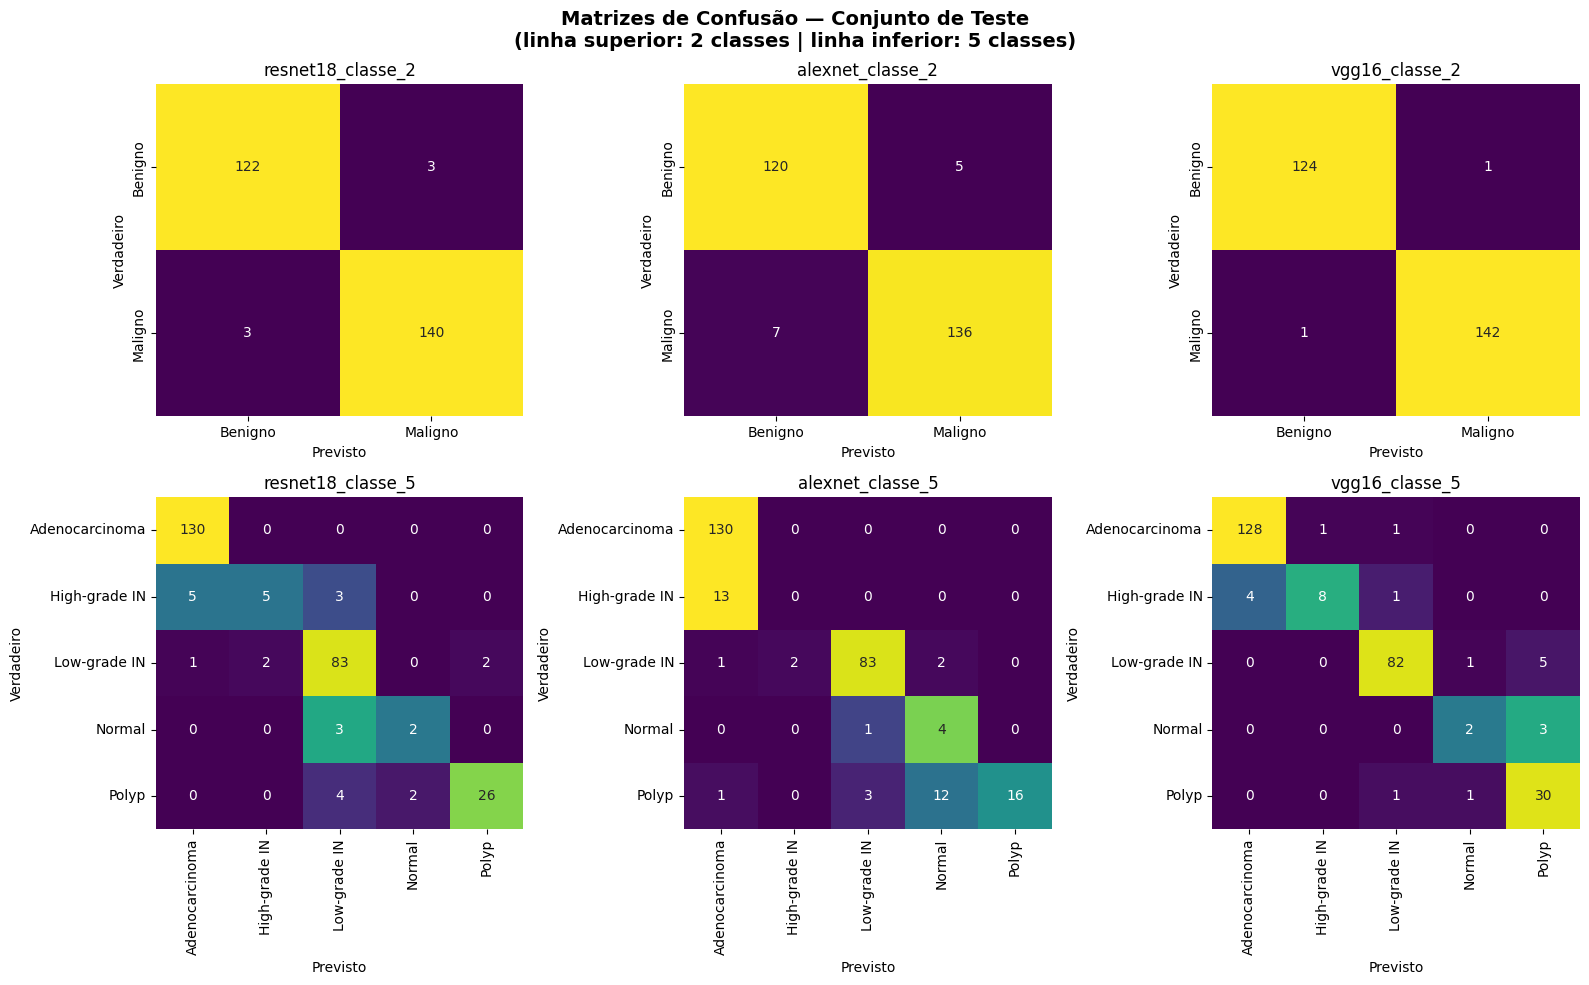

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definindo a função que desenha a matriz
def plotar_matriz_confusao(nome_experimento, resultados_teste, ax):
    matriz = np.array(resultados_teste[nome_experimento]['matriz_confusao'])
    nomes_classes = resultados_teste[nome_experimento]['nomes_classes']

    # normaliza por linha (mostra % em vez de contagem bruta) -- ajuda a comparar classes de tamanhos diferentes
    matriz_normalizada = matriz.astype('float') / matriz.sum(axis=1, keepdims=True)

    #Desenhando o heatmap
    sns.heatmap(
        matriz_normalizada,
        annot = matriz,  # mostra o número absoluto dentro de cada célula
        fmt = 'd',        # formato inteiro para os números mostrados
        cmap = 'viridis',
        xticklabels = nomes_classes,
        yticklabels = nomes_classes,
        ax=ax,
        cbar=False
    )
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Verdadeiro')
    ax.set_title(nome_experimento)

# monta um grid 2x3 (uma matriz por experimento)
experimentos = [
    'resnet18_classe_2', 'alexnet_classe_2', 'vgg16_classe_2',
    'resnet18_classe_5', 'alexnet_classe_5', 'vgg16_classe_5'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, exp in enumerate(experimentos):
    plotar_matriz_confusao(exp, resultados_teste, axes[i])

fig.suptitle('Matrizes de Confusão — Conjunto de Teste\n(linha superior: 2 classes | linha inferior: 5 classes)',
             fontsize = FONTE_TITULO_GERAL, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/resultados_ebhi/matrizes_confusao.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()



## **5.3.Loss e Acurácia**


---



1.  **Carrega 6 arquivos JSON com o histórico de treino de cada experimento;**
2.   **É montada uma figura com 4 gráficos**;
3.  **Cada gráfico sobrepõe as curvas de treino e validação das 3 arquiteturas simultaneamente**;
4.  **A figura é salva como imagem e exibida na tela.**





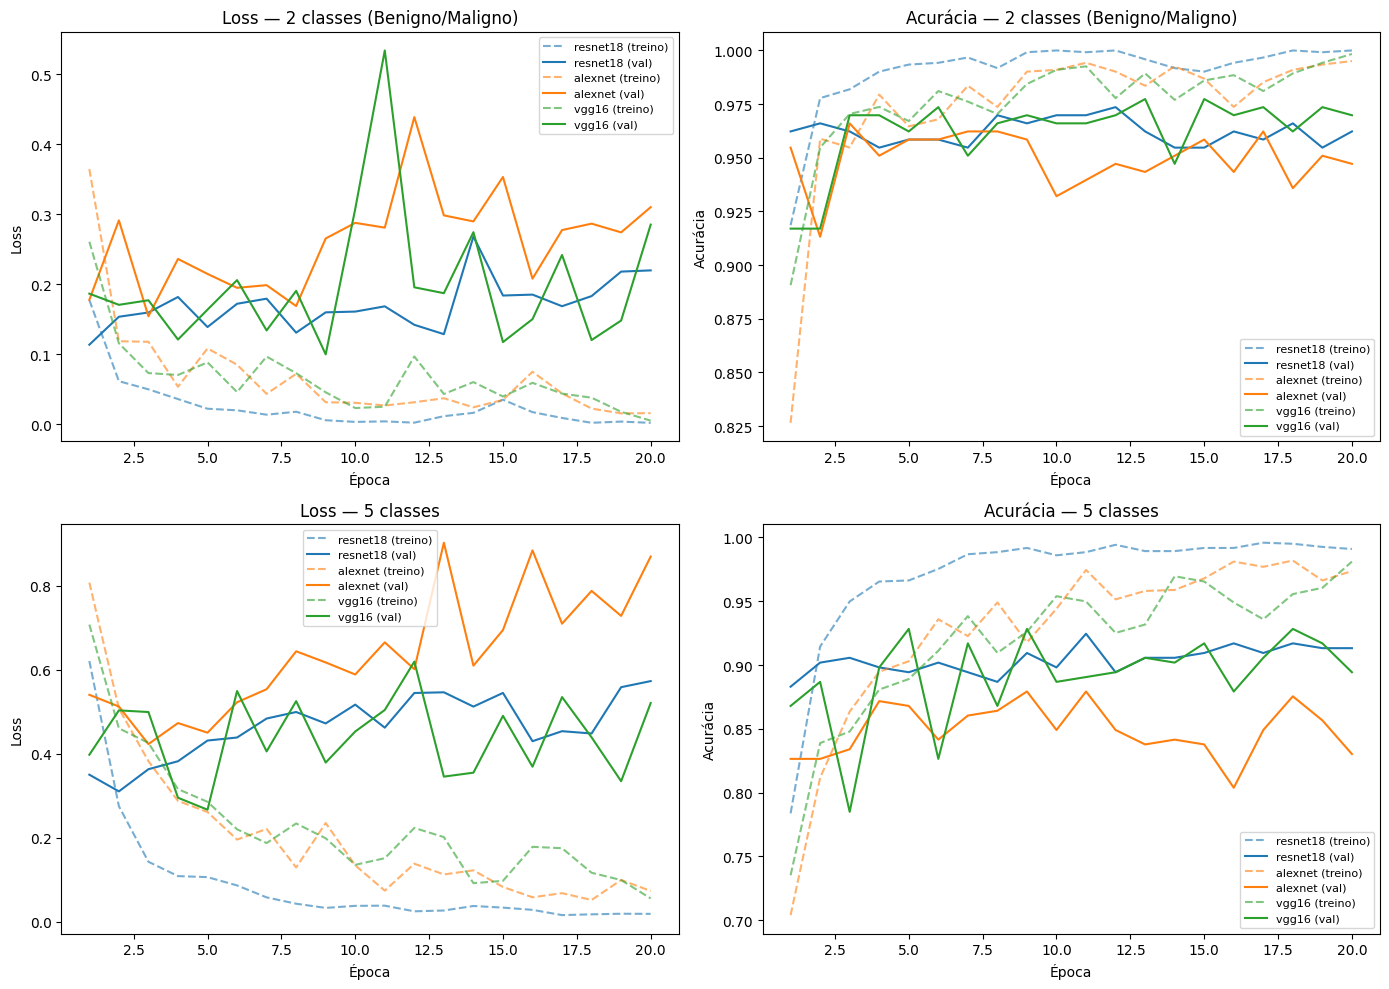

In [27]:
import matplotlib.pyplot as plt
import json
import os

pasta_resultados = '/content/drive/MyDrive/resultados_ebhi'
experimentos = [
    'resnet18_classe_2', 'alexnet_classe_2', 'vgg16_classe_2',
    'resnet18_classe_5', 'alexnet_classe_5', 'vgg16_classe_5'
]

# carrega todos os históricos
historicos = {}
for exp in experimentos:
    with open(os.path.join(pasta_resultados, f"{exp}_historico.json")) as f:
        historicos[exp] = json.load(f)

# monta um grid 2x2: linha 1 = 2 classes, linha 2 = 5 classes | coluna 1 = loss, coluna 2 = acc
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cores = {'resnet18': 'tab:blue', 'alexnet': 'tab:orange', 'vgg16': 'tab:green'}

for i, cenario in enumerate(['classe_2', 'classe_5']):
    for arquitetura in ['resnet18', 'alexnet', 'vgg16']:
        exp = f"{arquitetura}_{cenario}"
        h = historicos[exp]
        epocas = range(1, len(h['treino_loss']) + 1)

        # gráfico de loss (esquerda)
        axes[i, 0].plot(epocas, h['treino_loss'], '--', color=cores[arquitetura], alpha=0.6, label=f'{arquitetura} (treino)')
        axes[i, 0].plot(epocas, h['val_loss'], '-', color=cores[arquitetura], label=f'{arquitetura} (val)')

        # gráfico de acurácia (direita)
        axes[i, 1].plot(epocas, h['treino_acc'], '--', color=cores[arquitetura], alpha=0.6, label=f'{arquitetura} (treino)')
        axes[i, 1].plot(epocas, h['val_acc'], '-', color=cores[arquitetura], label=f'{arquitetura} (val)')

    nome_cenario = '2 classes (Benigno/Maligno)' if cenario == 'classe_2' else '5 classes'
    axes[i, 0].set_title(f'Loss — {nome_cenario}')
    axes[i, 0].set_xlabel('Época')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend(fontsize = 8)

    axes[i, 1].set_title(f'Acurácia — {nome_cenario}')
    axes[i, 1].set_xlabel('Época')
    axes[i, 1].set_ylabel('Acurácia')
    axes[i, 1].legend(fontsize = 8)

plt.tight_layout()
plt.savefig(os.path.join(pasta_resultados, 'curvas_treino.png'), dpi=150, bbox_inches='tight')
plt.show()

## **5.4.métricas de desempenho**


---



In [31]:
import pandas as pd
!pip install tabulate

# Carrega o arquivo JSON com os resultados das avaliações de teste
with open(os.path.join(pasta_resultados, 'avaliacao_teste_completa.json')) as f:
    resultados_teste = json.load(f)

linhas_resumo = []

# Percorre a lista de experimentos para extrair e estruturar as métricas
for exp in experimentos:
    # Separa o nome da arquitetura e o cenário a partir da última ocorrência do caractere '_'
    arquitetura, cenario = exp.rsplit('_', 1)
    # Obtém o relatório de métricas específico do experimento atual
    rel = resultados_teste[exp]['relatorio']

    # Adiciona os dados extraídos formatados à lista de resumo
    linhas_resumo.append({
        'Arquitetura': arquitetura.upper(),
        'Cenário': '2 classes' if cenario == 'classe_2' else '5 classes',
        'Acurácia': round(rel['accuracy'], 4),
        'Precisão (macro)': round(rel['macro avg']['precision'], 4),
        'Recall (macro)': round(rel['macro avg']['recall'], 4),
        'F1-score (macro)': round(rel['macro avg']['f1-score'], 4),
    })

# Converte a lista de dicionários em um DataFrame do Pandas
tabela_resumo = pd.DataFrame(linhas_resumo)

# Ordena a tabela por 'Cenário' (ordem alfabética) e depois por 'F1-score' (do maior para o menor)
tabela_resumo = tabela_resumo.sort_values(['Cenário', 'F1-score (macro)'], ascending=[True, False])

# Define o alinhamento dos cabeçalhos como centralizado
pd.set_option('display.colheader_justify', 'center')

# Exibe a tabela no terminal formatada e sem exibir a coluna de índices padrões
print(tabela_resumo.to_markdown(index = False, tablefmt = "grid", colalign = ["center"] * len(tabela_resumo.columns)))

# salva como CSV
tabela_resumo.to_csv(os.path.join(pasta_resultados, 'tabela_resumo_final.csv'), index = False)

+-----------------+-----------+------------+--------------------+------------------+--------------------+
|   Arquitetura   |  Cenário  |  Acurácia  |  Precisão (macro)  |  Recall (macro)  |  F1-score (macro)  |
+=================+===========+============+====================+==================+====================+
|  VGG16_CLASSE   | 5 classes |   0.9925   |       0.9925       |      0.9925      |       0.9925       |
+-----------------+-----------+------------+--------------------+------------------+--------------------+
| RESNET18_CLASSE | 5 classes |   0.9776   |       0.9775       |      0.9775      |       0.9775       |
+-----------------+-----------+------------+--------------------+------------------+--------------------+
| ALEXNET_CLASSE  | 5 classes |   0.9552   |       0.9547       |      0.9555      |       0.9551       |
+-----------------+-----------+------------+--------------------+------------------+--------------------+
|  VGG16_CLASSE   | 5 classes |   0.9328   |  

In [32]:
linhas_detalhe = []

for arquitetura in ['resnet18', 'alexnet', 'vgg16']:
    exp = f"{arquitetura}_classe_5"
    rel = resultados_teste[exp]['relatorio']
    nomes_classes = resultados_teste[exp]['nomes_classes']

    for classe in nomes_classes:
        linhas_detalhe.append({
            'Arquitetura': arquitetura.upper(),
            'Classe': classe,
            'Precisão': round(rel[classe]['precision'], 3),
            'Recall': round(rel[classe]['recall'], 3),
            'F1-score': round(rel[classe]['f1-score'], 3),
            'Suporte (n imagens)': int(rel[classe]['support'])
        })

tabela_detalhe = pd.DataFrame(linhas_detalhe)
tabela_pivot = tabela_detalhe.pivot(index='Classe', columns='Arquitetura', values='F1-score')

print("F1-score por classe e arquitetura (5 classes):\n")
print(tabela_pivot.to_markdown(index = False, tablefmt = "grid", colalign = ["center"] * len(tabela_pivot.columns)))

tabela_detalhe.to_csv(os.path.join(pasta_resultados, 'tabela_detalhe_5classes.csv'), index=False)

F1-score por classe e arquitetura (5 classes):

+-----------+------------+---------+
|  ALEXNET  |  RESNET18  |  VGG16  |
+===========+============+=========+
|   0.945   |   0.977    |  0.977  |
+-----------+------------+---------+
|     0     |    0.5     |  0.727  |
+-----------+------------+---------+
|   0.949   |   0.917    |  0.948  |
+-----------+------------+---------+
|   0.348   |   0.444    |  0.444  |
+-----------+------------+---------+
|   0.667   |   0.867    |  0.857  |
+-----------+------------+---------+
